# LLM-Driven Automated Trading Agent

**MMAI 5090 - Business Applications of AI II | Group Project #2**

This notebook demonstrates the full pipeline of our sentiment-augmented trading system:

1. **Stock Screening** - Dynamically select stocks from a 29-stock universe
2. **News Ingestion** - Fetch real financial news articles via Alpaca, FMP, and Finnhub
3. **LLM Sentiment Analysis** - Classify headlines using FinBERT (finance-domain BERT)
4. **Signal Generation** - Combine technical indicators + sentiment into trading signals
5. **Trade Decisions** - Show actual BUY / HOLD / SELL decisions
6. **Backtest Results** - 12-month performance vs SPY benchmark


---
## Section 1: Setup and Configuration
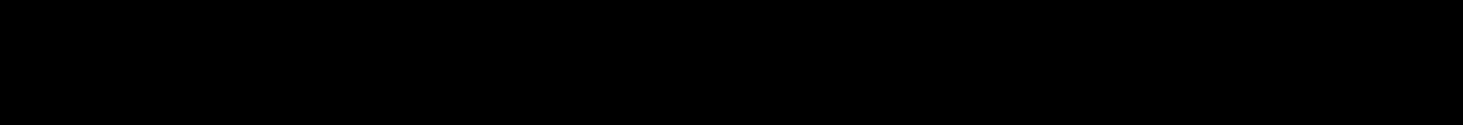
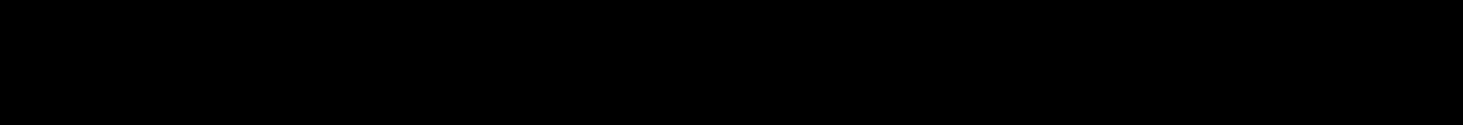
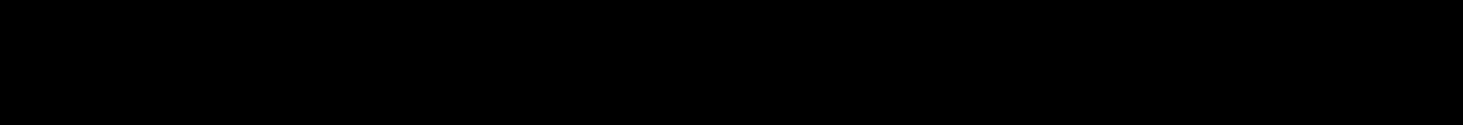
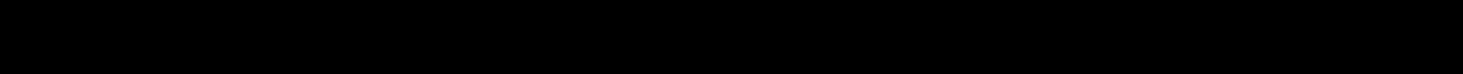

#### Market Data
1. Alpaca StockHistoricalDataClient   (requires ALPACA_API_KEY + ALPACA_SECRET_KEY)

   ↓ if degraded / empty result
2. yfinance.download()                (no credentials required)

      ↓ if both fail
   Return empty DataFrame + log error

#### News Data
1. Alpaca NewsClient

      ↓ if degraded OR < MIN_NEWS_ARTICLES returned
2. FMP Stock News API

      ↓ always supplemented by
3. Finnhub Company News API

      ↓ if still < MIN_NEWS_ARTICLES
4. RSS feeds: Yahoo Finance, WSJ, CNBC, Reuters

      ↓ if all fail
   Return empty list + log warning

5. Google News RSS (gap-fill only)

   → Available for historical coverage via yahoo_news_provider.py

   → Scrapes month-by-month via Google News RSS with date-range queries

   → Not active in default pipeline (tested but yielded signal dilution)


In [158]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.WARNING)

import random
from datetime import datetime, timedelta, timezone

# Core infrastructure
from src.data.market_data_handler import MarketDataHandler
from src.data.news_fetcher import NewsFetcher
from src.nlp.sentiment_agent import SentimentAgent
from src.strategy.stock_screener import StockScreener, DEFAULT_UNIVERSE
from src.strategy.signal_rules import evaluate_entry, evaluate_exit

# Initialize handlers
market_handler = MarketDataHandler()
news_fetcher = NewsFetcher()
sentiment_agent = SentimentAgent(window_hours=24)

# Configuration
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'NVDA']
DEMO_TICKER = 'AAPL'  # Primary ticker for step-by-step walkthrough

print('System initialized successfully.')
print(f'  Market Data:  Alpaca + yfinance fallback')
print(f'  News Sources: Alpaca News, FMP, Finnhub, RSS')
print(f'  NLP Model:    FinBERT (ProsusAI/finbert)')
print(f'  Strategy:     SMA-50 + Sentiment + RSI + ADX')
print(f'  Tickers:      {TICKERS}')


System initialized successfully.
  Market Data:  Alpaca + yfinance fallback
  News Sources: Alpaca News, FMP, Finnhub, RSS
  NLP Model:    FinBERT (ProsusAI/finbert)
  Strategy:     SMA-50 + Sentiment + RSI + ADX
  Tickers:      ['AAPL', 'MSFT', 'GOOGL', 'NVDA']


---
## Section 2: Dynamic Stock Screening



### Stock Ticker Reference

- **Tech**
  - `AAPL` — Apple
  - `MSFT` — Microsoft
  - `GOOGL` — Alphabet (Google)
  - `NVDA` — NVIDIA
  - `META` — Meta Platforms
  - `AMZN` — Amazon
  - `TSLA` — Tesla
  - `AMD` — Advanced Micro Devices
  - `CRM` — Salesforce
  - `ORCL` — Oracle

- **Finance**
  - `JPM` — JPMorgan Chase
  - `GS` — Goldman Sachs
  - `V` — Visa
  - `MA` — Mastercard

- **Healthcare**
  - `JNJ` — Johnson & Johnson
  - `UNH` — UnitedHealth Group
  - `PFE` — Pfizer

- **Consumer**
  - `WMT` — Walmart
  - `COST` — Costco
  - `DIS` — Disney

- **Energy**
  - `XOM` — Exxon Mobil
  - `CVX` — Chevron
  - `COP` — ConocoPhillips
  - `SLB` — SLB (Schlumberger)
  - `EOG` — EOG Resources
  - `MPC` — Marathon Petroleum
  - `OXY` — Occidental Petroleum

- **Industrial**
  - `BA` — Boeing
  - `CAT` — Caterpillar

In [159]:
# Screen 29 stocks across 6 sectors: Tech, Energy, Finance, Healthcare, Consumer, Industrial
# Each stock is evaluated on Liquidity, Trend Strength, and volatility
# Shuffle and revaluate for every 21 days

print(f'Screening {len(DEFAULT_UNIVERSE)} stocks across 6 sectors...\n')
print(f'Universe: {DEFAULT_UNIVERSE}\n')

screener = StockScreener(market_handler, news_fetcher)
results = screener.screen(top_n=5)

# Display ranking table
print(f'{"Rank":<6} {"Ticker":<8} {"Total":<8} {"Liquidity":<11} {"Trend":<8} {"Volatility":<12} {"News":<8}')
print('-' * 70)
for r in results[:10]:  # Show top 10
    marker = ' >> ' if r['rank'] <= 5 else '    '
    print(f"{marker}{r['rank']:<5} {r['ticker']:<8} {r['total_score']:<8.1f} "
          f"{r['liquidity_score']:<11.1f} {r['trend_score']:<8.1f} "
          f"{r['volatility_score']:<12.1f} {r['news_score']:<8.1f}")

selected_tickers = [r['ticker'] for r in results[:5]]
print(f'\nSelected for trading: {selected_tickers}')
print(f'\nFor this demo, we will walk through {DEMO_TICKER} step by step.')

# Update tickers to use screener selection

print(f'\nNote: The screener shows the CURRENT top stocks.')
print(f'The backtest below uses the default portfolio for a fair 12-month comparison.')


2026-03-31 20:28:30,262 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for AAPL bars (41 rows)
2026-03-31 20:28:30,269 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for AAPL news (582 articles)
2026-03-31 20:28:30,273 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for MSFT bars (41 rows)
2026-03-31 20:28:30,285 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for MSFT news (938 articles)
2026-03-31 20:28:30,289 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for GOOGL bars (41 rows)
2026-03-31 20:28:30,298 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for GOOGL news (779 articles)
2026-03-31 20:28:30,302 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for NVDA bars (41 rows)
2026-03-31 20:28:30,312 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for NVDA news (1132 articles)
2026-03-31 20:28:30,315 | INFO     | src.data.market_data_han

Screening 29 stocks across 6 sectors...

Universe: ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META', 'AMZN', 'TSLA', 'AMD', 'CRM', 'ORCL', 'JPM', 'GS', 'V', 'MA', 'JNJ', 'UNH', 'PFE', 'WMT', 'COST', 'DIS', 'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC', 'OXY', 'BA', 'CAT']



2026-03-31 20:28:30,459 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for COST bars (41 rows)
2026-03-31 20:28:30,466 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for COST news (358 articles)
2026-03-31 20:28:30,471 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for DIS bars (41 rows)
2026-03-31 20:28:30,477 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for DIS news (291 articles)
2026-03-31 20:28:30,481 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for XOM bars (41 rows)
2026-03-31 20:28:30,487 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for XOM news (434 articles)
2026-03-31 20:28:30,491 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for CVX bars (41 rows)
2026-03-31 20:28:30,498 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for CVX news (478 articles)
2026-03-31 20:28:30,502 | INFO     | src.data.market_data_handler | Ma

Rank   Ticker   Total    Liquidity   Trend    Volatility   News    
----------------------------------------------------------------------
 >> 1     AMZN     80.8     21.8        0.0      34.0         25.0    
 >> 2     MSFT     80.5     21.5        0.0      34.0         25.0    
 >> 3     AAPL     79.8     20.8        0.0      34.0         25.0    
 >> 4     GOOGL    79.5     20.5        0.0      34.0         25.0    
 >> 5     NVDA     73.3     24.3        0.0      24.0         25.0    
    6     XOM      72.0     18.0        0.0      34.0         20.0    
    7     V        70.8     16.8        0.0      34.0         20.0    
    8     WMT      70.5     16.5        0.0      34.0         20.0    
    9     MA       70.2     16.2        0.0      34.0         20.0    
    10    CVX      70.0     16.0        0.0      34.0         20.0    

Selected for trading: ['AMZN', 'MSFT', 'AAPL', 'GOOGL', 'NVDA']

For this demo, we will walk through AAPL step by step.

Note: The screener shows the 

---
## Section 3: News Ingestion

In [160]:
# Fetch recent news articles for the demo ticker
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=7)  # Last 7 days for demo

articles = news_fetcher.get_recent_news(DEMO_TICKER, start=start_date, end=end_date)

print(f'News Ingestion Results for {DEMO_TICKER}')
print(f'=' * 60)
print(f'Period:   {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}')
print(f'Articles: {len(articles)} total\n')

# Show provider breakdown
providers = {}
for a in articles:
    p = a.get('provider', 'unknown')
    providers[p] = providers.get(p, 0) + 1
print('Articles by provider:')
for p, count in sorted(providers.items(), key=lambda x: -x[1]):
    print(f'  {p:<25} {count:>5} articles')

# Show sample headlines
print(f'\nSample Headlines (most recent 10):')
print('-' * 60)
sorted_articles = sorted(articles, key=lambda a: a.get('published_at', ''), reverse=True)
for a in sorted_articles[:10]:
    headline = a.get('headline', 'N/A')[:80]
    source = a.get('source', 'N/A')[:15]
    pub = a.get('published_at', '')
    if hasattr(pub, 'strftime'):
        pub = pub.strftime('%Y-%m-%d %H:%M')
    else:
        pub = str(pub)[:16]
    print(f'  [{pub}] {source:<15} {headline}')


2026-03-31 20:28:49,357 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for AAPL news (316 articles)


News Ingestion Results for AAPL
Period:   2026-03-25 to 2026-04-01
Articles: 316 total

Articles by provider:
  finnhub                     162 articles
  fmp                          95 articles
  alpaca_news                  59 articles

Sample Headlines (most recent 10):
------------------------------------------------------------
  [2026-03-31T23:25] Yahoo           Warren Buffett Made a $19.8 Billion Bet and It's Not on AI
  [2026-03-31T22:37] Yahoo           Wedbush Reiterates Outperform on Apple Inc. (AAPL) Amid Anticipation of Foldable
  [2026-03-31T21:33] Yahoo           Amazon partners up with Delta to provide high-speed internet
  [2026-03-31T21:12] Yahoo           Assessing Apple (AAPL) Valuation After Recent Share Price Pullback And Tariff Co
  [2026-03-31T20:22] benzinga        Palantir, Tesla, Apple Top Iran Retaliation List: 'A US Company Will Be Destroye
  [2026-03-31T20:03] benzinga        Buffett Won't Buy Apple Yet — That's A Problem For ETF Investors
  [2026-03-31T

---
## Section 4: LLM Sentiment Analysis (FinBERT)


In [161]:
# Run FinBERT sentiment analysis on recent articles
# The SentimentAgent handles batching, caching, and aggregation
recent_articles = sorted_articles[:20]  # Use 20 most recent for demo speed
ref_time = datetime.now(timezone.utc)

result = sentiment_agent.analyze(DEMO_TICKER, recent_articles, reference_time=ref_time)

print(f'FinBERT Sentiment Analysis for {DEMO_TICKER}')
print(f'=' * 60)
print(f'Overall Sentiment:  {result.get("sentiment", "N/A")}')
print(f'Conviction Score:   {result.get("conviction_score", 0):.1f} / 10.0')
print(f'Articles Analyzed:  {result.get("source_count", 0)}')
print(f'Provider:           {result.get("provider", "finbert")}')

# Show individual article-level scores from the events
events = result.get('events', [])
if events:
    print(f'\nArticle-Level Breakdown (top {min(10, len(events))}):')
    print(f'{"Sentiment":<12} {"Conv.":<8} {"Headline":<60}')
    print('-' * 80)
    for ev in events[:10]:
        sent = ev.get('sentiment', 'N/A')
        conv = ev.get('conviction_score', 0)
        hl = ev.get('headline', 'N/A')[:58]
        print(f'  {sent:<10} {conv:<8.1f} {hl}')

print(f'\nInterpretation: With sentiment={result.get("sentiment")}, '
      f'conviction={result.get("conviction_score", 0):.1f}, ', end='')
threshold = 7.0
if result.get('sentiment') == 'POSITIVE' and result.get('conviction_score', 0) > threshold:
    print(f'the sentiment gate PASSES (conviction > {threshold}).')
else:
    print(f'the sentiment gate does NOT pass (need POSITIVE with conviction > {threshold}).')


FinBERT Sentiment Analysis for AAPL
Overall Sentiment:  POSITIVE
Conviction Score:   8.1 / 10.0
Articles Analyzed:  20
Provider:           finbert

Interpretation: With sentiment=POSITIVE, conviction=8.1, the sentiment gate PASSES (conviction > 7.0).


---
## Section 5: Signal Generation Logic


* Liquidity Score (0–33): rewards stocks that trade a lot of dollar volume, because they are easier to enter and exit.
* Trend Score (0–33): rewards stocks that have been trading above the 50-day moving average and are currently above it, so it favors sustained upward trends.
* Volatility Score (0–34): rewards stocks with moderate volatility, since they move enough to create opportunity but are not so unstable that they become hard to trade.
* News Coverage Score (0–25, live only): rewards stocks that have more recent news coverage, because more news creates more sentiment input for the model.

In [163]:
# Fetch current market data with technical indicators
lookback_start = datetime.now(timezone.utc) - timedelta(days=180)
bars_df = market_handler.get_historical_bars(
    DEMO_TICKER, start=lookback_start, end=datetime.now(timezone.utc), timeframe='1Day'
)
bars_df = market_handler.add_moving_averages(bars_df, windows=[50])
bars_df = market_handler.add_rsi(bars_df, period=14)
bars_df = market_handler.add_adx(bars_df, period=14)

# Get the latest bar
latest = bars_df.iloc[-1]
close = float(latest['close'])
sma_50_raw = latest.get('SMA_50', None)
import math
sma_50 = float(sma_50_raw) if sma_50_raw is not None and not (isinstance(sma_50_raw, float) and math.isnan(sma_50_raw)) else 0.0
# If SMA-50 is 0 (not enough data in short lookback), use last 50 closes
if sma_50 == 0.0 and len(bars_df) >= 50:
    sma_50 = float(bars_df['close'].tail(50).mean())
rsi_14_raw = latest.get('RSI_14', None)
rsi_14 = float(rsi_14_raw) if rsi_14_raw is not None and not (isinstance(rsi_14_raw, float) and math.isnan(rsi_14_raw)) else 50.0
adx_14_raw = latest.get('ADX_14', None)
adx_14 = float(adx_14_raw) if adx_14_raw is not None and not (isinstance(adx_14_raw, float) and math.isnan(adx_14_raw)) else 0.0

print(f'Signal Generation for {DEMO_TICKER} (as of {latest["timestamp"].strftime("%Y-%m-%d")})')
print(f'=' * 60)
print(f'')
print(f'TECHNICAL INDICATORS:')
print(f'  Close Price:  ${close:.2f}')
print(f'  SMA-50:       ${sma_50:.2f}')
print(f'  RSI-14:       {rsi_14:.1f}')
print(f'  ADX-14:       {adx_14:.1f}')
print(f'')
print(f'SENTIMENT:')
print(f'  Label:        {result.get("sentiment", "N/A")}')
print(f'  Conviction:   {result.get("conviction_score", 0):.1f}')
print(f'')

# Evaluate each entry condition individually
print(f'ENTRY CONDITIONS (ALL must pass):')
print(f'-' * 50)

cond_1 = close > sma_50
print(f'  [{'PASS' if cond_1 else 'FAIL'}]  Price > SMA-50:      ${close:.2f} {'>' if cond_1 else '<='} ${sma_50:.2f}')

cond_2 = adx_14 >= 20
print(f'  [{'PASS' if cond_2 else 'FAIL'}]  ADX >= 20:           {adx_14:.1f} {">=" if cond_2 else "<"} 20')

sent_label = result.get('sentiment', 'NEUTRAL')
conv_score = result.get('conviction_score', 0)
cond_3 = sent_label == 'POSITIVE'
print(f'  [{'PASS' if cond_3 else 'FAIL'}]  Sentiment POSITIVE:  {sent_label}')

cond_4 = conv_score > 7.0
print(f'  [{'PASS' if cond_4 else 'FAIL'}]  Conviction > 7.0:    {conv_score:.1f}')

cond_5 = rsi_14 < 70
print(f'  [{'PASS' if cond_5 else 'FAIL'}]  RSI < 70:            {rsi_14:.1f}')

all_pass = cond_1 and cond_2 and cond_3 and cond_4 and cond_5
print(f'')
print(f'  Result: {"ALL CONDITIONS MET -> BUY SIGNAL" if all_pass else "CONDITIONS NOT MET -> NO ACTION"}')


2026-03-31 20:29:21,528 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for AAPL bars (123 rows)


Signal Generation for AAPL (as of 2026-03-31)

TECHNICAL INDICATORS:
  Close Price:  $253.73
  SMA-50:       $260.00
  RSI-14:       50.0
  ADX-14:       0.0

SENTIMENT:
  Label:        POSITIVE
  Conviction:   8.1

ENTRY CONDITIONS (ALL must pass):
--------------------------------------------------
  [FAIL]  Price > SMA-50:      $253.73 <= $260.00
  [FAIL]  ADX >= 20:           0.0 < 20
  [PASS]  Sentiment POSITIVE:  POSITIVE
  [PASS]  Conviction > 7.0:    8.1
  [PASS]  RSI < 70:            50.0

  Result: CONDITIONS NOT MET -> NO ACTION


---
## Section 6: Trade Decision (Buy / Hold / Sell)

In [164]:
# Build the market snapshot the way the signal engine expects it
market_snapshot = {
    'ticker': DEMO_TICKER,
    'close': close,
    'sma_50': sma_50,
    'rsi_14': rsi_14,
    'adx_14': adx_14,
    'is_market_open': True,
}

sentiment_snapshot = {
    'ticker': DEMO_TICKER,
    'sentiment': result.get('sentiment', 'NEUTRAL'),
    'conviction_score': result.get('conviction_score', 0),
    'generated_at': datetime.now(timezone.utc),
    'sentiment_rolling': result.get('conviction_score', 0) if result.get('sentiment') == 'POSITIVE' else -result.get('conviction_score', 0),
}

# --- Entry Decision ---
entry_decision = evaluate_entry(
    market=market_snapshot,
    sentiment=sentiment_snapshot,
    conviction_threshold=7.0,
)

print(f'TRADE DECISIONS for {DEMO_TICKER}')
print(f'=' * 60)
print(f'')
print(f'--- Entry Evaluation (no existing position) ---')
print(f'  Signal:  {entry_decision.get("signal", "N/A")}')
print(f'  Reason:  {entry_decision.get("reason", "N/A")}')
print(f'')

# --- Exit Decision (simulate holding a position) ---
hypothetical_entry_price = close * 0.95  # Pretend we bought 5% lower
stop_loss_price = hypothetical_entry_price * 0.93  # 7% stop-loss

position_snapshot = {
    'ticker': DEMO_TICKER,
    'entry_price': hypothetical_entry_price,
    'stop_loss_price': stop_loss_price,
}

exit_decision = evaluate_exit(
    market=market_snapshot,
    sentiment=sentiment_snapshot,
    position=position_snapshot,
)

print(f'--- Exit Evaluation (hypothetical position from ${hypothetical_entry_price:.2f}) ---')
print(f'  Entry Price:     ${hypothetical_entry_price:.2f}')
print(f'  Stop-Loss:       ${stop_loss_price:.2f}')
print(f'  Current Price:   ${close:.2f} ({((close - hypothetical_entry_price) / hypothetical_entry_price * 100):.1f}% P/L)')
print(f'  Signal:  {exit_decision.get("signal", "N/A")}')
print(f'  Reason:  {exit_decision.get("reason", "N/A")}')
print(f'')

# Summary
print(f'--- Summary ---')
if entry_decision.get('signal') == 'BUY':
    print(f'  Decision: BUY {DEMO_TICKER} at ${close:.2f}')
    print(f'  Position Size: 12% of portfolio ($12,000 on $100k portfolio)')
    print(f'  Stop-Loss: ${close * 0.93:.2f} (-7%)')
    print(f'  Take-Profit: ${close * 1.10:.2f} (+10%)')
else:
    print(f'  Decision: NO ACTION on {DEMO_TICKER}')
    print(f'  The system will check again on the next trading day.')
    print(f'  All {len(TICKERS)} tickers are evaluated independently each day.')


TRADE DECISIONS for AAPL

--- Entry Evaluation (no existing position) ---
  Signal:  NO_ACTION
  Reason:  Entry blocked: price (253.73) ≤ SMA-50 (260.00); ADX (0.0) < 20 — choppy market.

--- Exit Evaluation (hypothetical position from $241.04) ---
  Entry Price:     $241.04
  Stop-Loss:       $224.17
  Current Price:   $253.73 (5.3% P/L)
  Signal:  EXIT
  Reason:  Trend filter failed: close 253.73 < SMA-50 260.00.

--- Summary ---
  Decision: NO ACTION on AAPL
  The system will check again on the next trading day.
  All 4 tickers are evaluated independently each day.


- **SMA-50 (50-Day Simple Moving Average)**: The average closing price over the past 50 trading days
- **MA (Moving Average)**: A general term for an average price over time used to smooth price movements
- **RSI (Relative Strength Index)**: A momentum indicator that shows whether a stock may be overbought or oversold
- **ADX (Average Directional Index)**: A technical indicator that measures the strength of a trend

---
## Section 7: 12-Month Backtest Performance

In [165]:
# Run the full 12-month backtest
import pandas as pd
from src.backtest.backtester import Backtester
from src.backtest.schemas import default_config
from src.data.utils import now_utc

MONTHS = 12
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=round(365.25 * MONTHS / 12))

print(f'Running 12-month backtest: {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}')
print(f'Tickers: {TICKERS}')
print(f'Benchmark: SPY buy-and-hold')
print(f'Initial Capital: $100,000')
print(f'')
print(f'Loading cached data (news + sentiment + market)...')

# Import the data fetching logic from run_backtest
import sys
sys.path.insert(0, '.')
from run_backtest import _fetch_ticker_data

# Fetch benchmark
bench_df = market_handler.get_historical_bars('SPY', start=start_date, end=end_date, timeframe='1Day')
bench_df = bench_df.rename(columns={'symbol': 'ticker'})
benchmark_rows = bench_df.to_dict('records')

# Fetch ticker data
all_market_rows = []
all_sentiment_rows = []
random.seed(42)

for ticker in TICKERS:
    m_rows, s_rows = _fetch_ticker_data(ticker, market_handler, news_fetcher, sentiment_agent, start_date, end_date)
    all_market_rows.extend(m_rows)
    all_sentiment_rows.extend(s_rows)

all_sentiment_rows.sort(key=lambda x: x.get('timestamp', x.get('generated_at', now_utc())))

# Apply cross-ticker correlation dampening (same as run_backtest.py)
by_date = {}
for r in all_sentiment_rows:
    dt = r.get('generated_at', r.get('timestamp'))
    if dt:
        d_str = dt.strftime('%Y-%m-%d')
        by_date.setdefault(d_str, []).append(r)
for d_str, daily_rows in by_date.items():
    strong = {r['ticker'] for r in daily_rows if r.get('sentiment')=='POSITIVE' and float(r.get('conviction_score',0))>=8.0}
    for r in daily_rows:
        comps = [t for t in TICKERS if t != r['ticker']]
        hits = sum(1 for c in comps if c in strong)
        if hits > 0:
            penalty = min(0.25, hits * 0.05)
            r['conviction_score'] = round(float(r.get('conviction_score',0)) * (1.0-penalty), 2)
            if 'sentiment_rolling' in r:
                r['sentiment_rolling'] = round(r['sentiment_rolling'] * (1.0-penalty), 3)

print(f'Data loaded: {len(all_market_rows)} market bars, {len(all_sentiment_rows)} sentiment records')
print(f'Running backtest simulation...')


2026-03-31 20:30:08,866 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for SPY bars (251 rows)
2026-03-31 20:30:08,873 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for AAPL bars (251 rows)
2026-03-31 20:30:08,900 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for AAPL news (3425 articles)


Running 12-month backtest: 2025-04-01 to 2026-04-01
Tickers: ['AAPL', 'MSFT', 'GOOGL', 'NVDA']
Benchmark: SPY buy-and-hold
Initial Capital: $100,000

Loading cached data (news + sentiment + market)...


2026-03-31 20:30:09,582 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for MSFT bars (251 rows)
2026-03-31 20:30:09,607 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for MSFT news (3784 articles)
2026-03-31 20:30:10,501 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for GOOGL bars (251 rows)
2026-03-31 20:30:10,547 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for GOOGL news (3931 articles)
2026-03-31 20:30:11,515 | INFO     | src.data.market_data_handler | MarketDataHandler: cache HIT for NVDA bars (251 rows)
2026-03-31 20:30:11,557 | INFO     | src.data.news_fetcher | NewsFetcher: cache HIT for NVDA news (5175 articles)


Data loaded: 1004 market bars, 1411 sentiment records
Running backtest simulation...


In [166]:
# Execute backtest
cfg = default_config(
    tickers=TICKERS,
    benchmark_ticker='SPY',
    start_date=start_date.strftime('%Y-%m-%d'),
    end_date=end_date.strftime('%Y-%m-%d'),
    initial_capital=100000.0,
    stop_loss_pct=0.07,
    take_profit_enabled=True,
    take_profit_pct=0.30,
    conviction_threshold=6.0,
    neg_conviction_threshold=8.0,
    equity_fraction=0.12,
)

bt = Backtester(cfg)
result = bt.run(market_rows=all_market_rows, sentiment_rows=all_sentiment_rows, benchmark_rows=benchmark_rows)

# Use the same report generator as run_backtest.py
from src.backtest.report_generator import print_report
print_report(result)



 BACKTEST REPORT

--- Summary ---
  Strategy                       sentiment_ma50_long_only
  Period                         2025-04-01 → 2026-03-31
  Initial Capital                $100,000.00
  Final Equity                   $115,456.85
  Total Return                   15.46%
  Max Drawdown                   -2.58%
  Sharpe Ratio                   1.559
  Calmar Ratio                   6.027
  Profit Factor                  2.385
  Win Rate                       56.06%
  Trade Count                    66
  Avg Win                        $719.37
  Avg Loss                       $-384.82
  Avg Holding (days)             11.4
  Exposure %                     52.59%
  Benchmark Return (SPY)         15.87%
  Benchmark Sharpe               0.903

--- Strategy vs SPY Benchmark ---
  Total Return              Strategy: 15.46%       SPY: 15.87%
  Max Drawdown              Strategy: -2.58%       SPY: -12.05%
  Sharpe Ratio              Strategy: 1.559        SPY: 0.903
  Trade Count          

---
## Section 8: Equity Curve Visualization


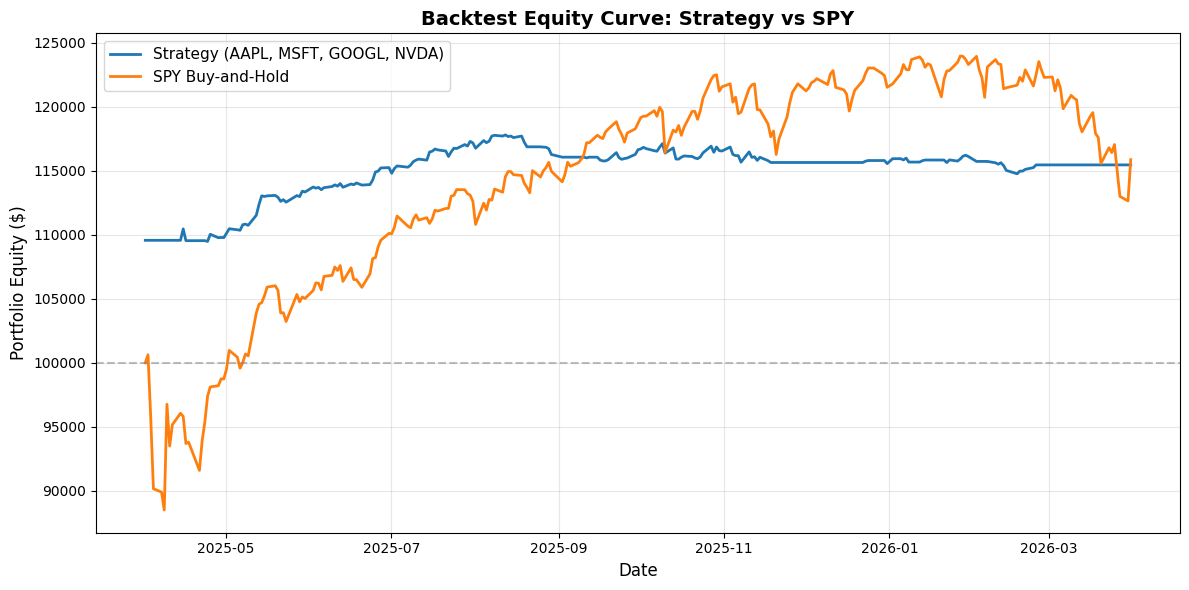

Equity curve saved to equity_curve_demo.png


In [167]:
%matplotlib inline
import matplotlib.pyplot as plt

curve = result.get('equity_curve', [])
bench_curve = result.get('benchmark', {}).get('equity_curve', [])

if curve:
    seen = {}
    for c in curve:
        seen[c['timestamp']] = c['equity']
    sorted_ts = sorted(seen.keys())
    dates = sorted_ts
    strat_eq = [seen[t] for t in sorted_ts]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(dates, strat_eq, label='Strategy (AAPL, MSFT, GOOGL, NVDA)', color='#1f77b4', linewidth=2)

    if bench_curve:
        bench_dates = [c['timestamp'] for c in bench_curve]
        bench_eq = [c['equity'] for c in bench_curve]
        ax.plot(bench_dates, bench_eq, label='SPY Buy-and-Hold', color='#ff7f0e', linewidth=2)

    ax.set_title('Backtest Equity Curve: Strategy vs SPY', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Portfolio Equity ($)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=100000, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    plt.tight_layout()
    plt.savefig('equity_curve_demo.png', dpi=150)
    plt.show()
    print('Equity curve saved to equity_curve_demo.png')
else:
    print('No equity curve data available.')
